<a href="https://colab.research.google.com/github/dheaadventina/Hands-On-Projek-ETS-Analisis-Regresi_Dhea-Adventina-Sandy/blob/main/Hands_On_Projek_ETS_Analisis_Regresi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving ovarian_cancer_survival_dataset.csv to ovarian_cancer_survival_dataset.csv
=== CEK MISSING VALUES ===
Missing Value: 0

=== CEK OUTLIERS ===

=== Variabel: CA125 ===
Sebelum pembersihan:
Outlier (IQR): 1, Outlier (Z-score > 3): 0, Grubbs: Tidak terdeteksi
Contoh nilai outlier: 388.1
Sesudah pembersihan:
Outlier (IQR): 0, Outlier (Z-score > 3): 0, Grubbs: Tidak terdeteksi

=== Variabel: Survival_Time_months ===
Sebelum pembersihan:
Outlier (IQR): 13, Outlier (Z-score > 3): 7, Grubbs: Terdeteksi
Contoh nilai outlier: 137.5, 160.5, 234.1, 164.4, 154.6
Sesudah pembersihan:
Outlier (IQR): 0, Outlier (Z-score > 3): 1, Grubbs: Tidak terdeteksi


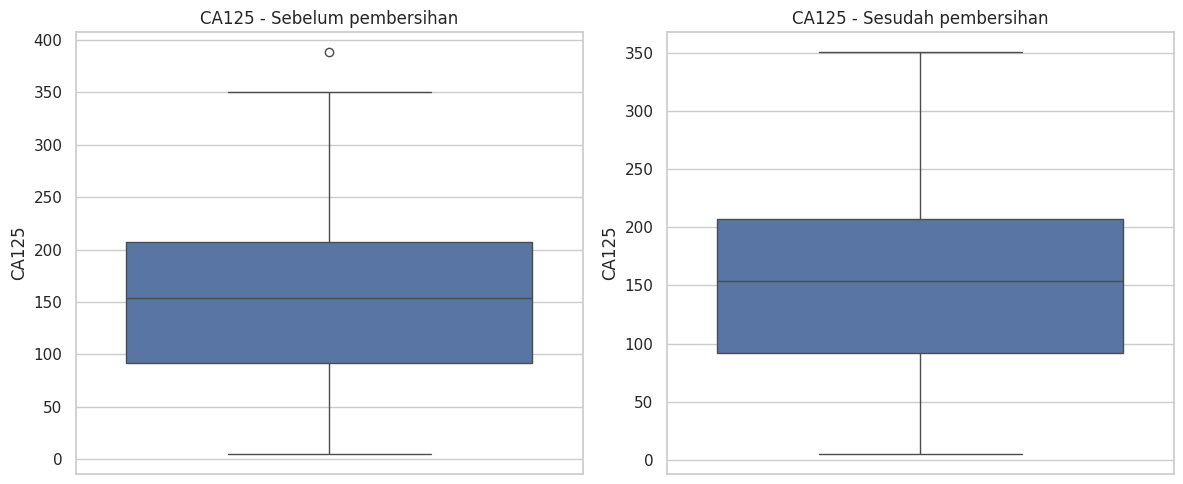

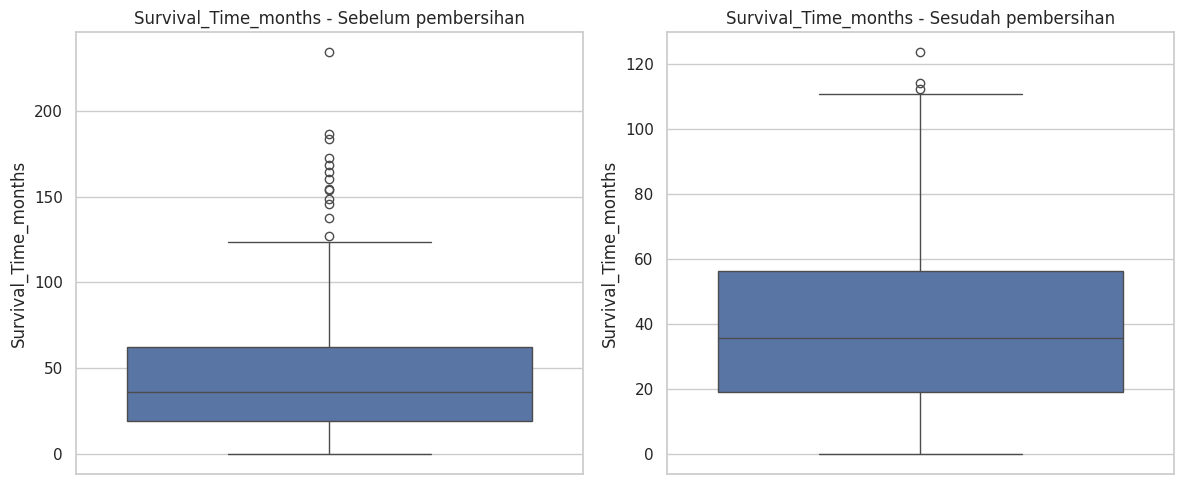


=== CEK INCONSISTENCY ===
CA125 negatif: 0
Survival_Time_months negatif: 0
Duplikasi data: 0

=== ANALISIS DESKRIPTIF STATISTIK PADA DATA===
--- Variabel: CA125 ---
Count: 300
Missing: 0
Mean: 151.66
Median: 153.74
Std Dev: 82.05
Min: 5.0
Q1: 92.1725
Q3: 207.5375
Max: 388.1
Nilai negatif (inconsistency): 0
Duplikasi data: 0
Jumlah outlier (IQR method): 1



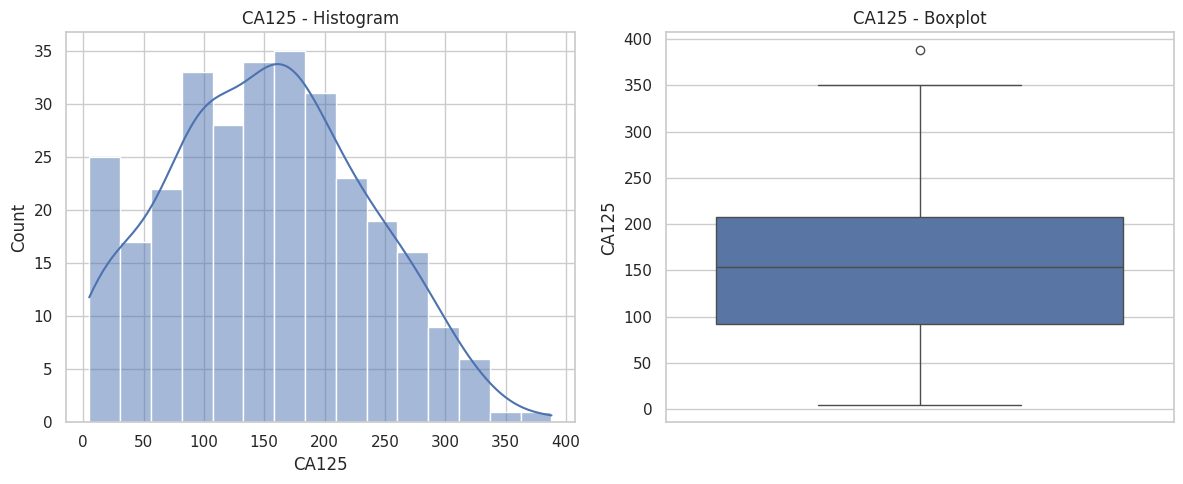

--- Variabel: Survival_Time_months ---
Count: 300
Missing: 0
Mean: 45.49
Median: 35.90
Std Dev: 37.54
Min: 0.0
Q1: 19.125
Q3: 62.324999999999996
Max: 234.1
Nilai negatif (inconsistency): 0
Duplikasi data: 0
Jumlah outlier (IQR method): 13



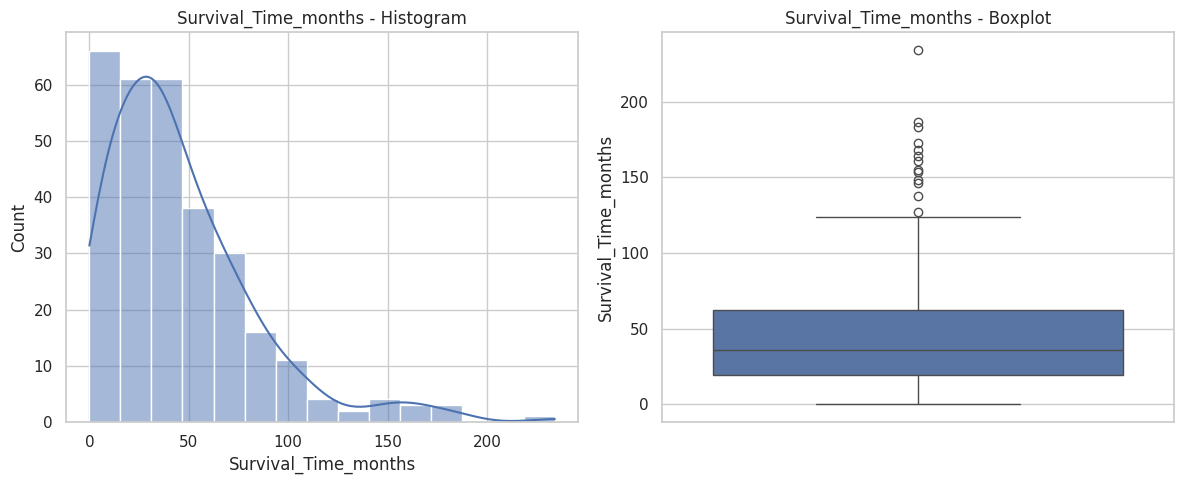


=== MENGHITUNG KOEFISIEN KORELASI PEARSON, UJI SIGNIFIKANSI KORELASI, DAN INTERPRETASINYA===

Korelasi Pearson antara CA125 dan Survival_Time_months: -0.030
Interpretasi: Korelasi sangat lemah negatif
Koefisien Korelasi Pearson: -0.030
P-value: 0.609
Tingkat Signifikansi (alpha): 0.05

Keputusan: Gagal Menolak Hipotesis Nol (H0)
Interpretasi Uji: Tidak ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier yang signifikan antara kadar CA125 dan Survival Time months.

=== POLA HUBUNGAN ANTAR VARIABEL===


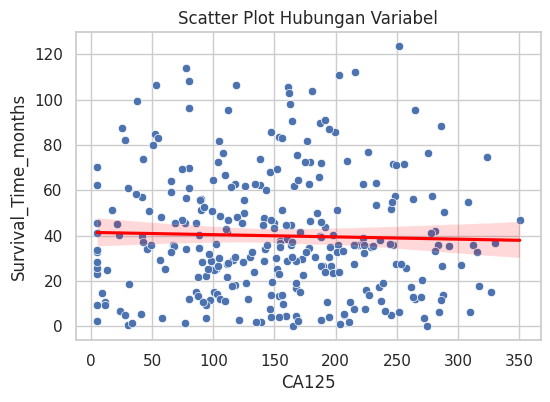


=== MODEL REGRESI LINEAR SEDERHANA===
                             OLS Regression Results                             
Dep. Variable:     Survival_Time_months   R-squared:                       0.001
Model:                              OLS   Adj. R-squared:                 -0.002
Method:                   Least Squares   F-statistic:                    0.2617
Date:                  Wed, 01 Apr 2026   Prob (F-statistic):              0.609
Time:                          04:39:38   Log-Likelihood:                -1415.8
No. Observations:                   300   AIC:                             2836.
Df Residuals:                       298   BIC:                             2843.
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

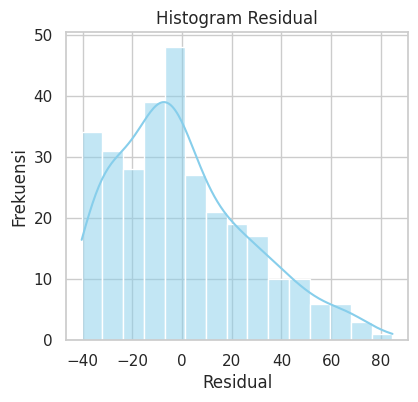


2. UJI HOMOSKEDASTISITAS (Breusch-Pagan):
Statistik Uji LM = 0.0359
P-value LM = 0.8497
Kesimpulan: Residual memenuhi asumsi homoskedastisitas (gagal menolak H0).


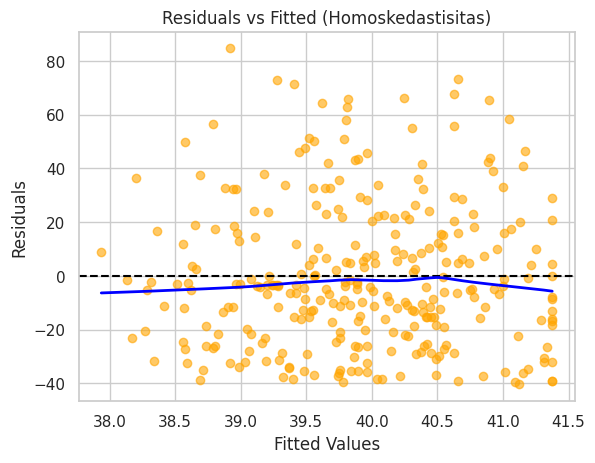


===IDENTIFIKASI MASALAH MODEL=== :
- Residual tidak normal → bisa gunakan transformasi (log) atau robust regression
- Tidak ditemukan pelanggaran asumsi utama

MEMBAGI DATA MENJADI TRAINING DAN TESTING SET:
Jumlah data training: 240
Jumlah data testing: 60

VALIDASI MODEL DAN METRIK PERFORMA:
METRIK PERFORMA MODEL
MSE  : 1206.1891
RMSE : 34.7302
MAE  : 23.6618
R²   : -0.0005

INTERPRETASI:
- Nilai RMSE sebesar 34.73 menunjukkan rata-rata kesalahan prediksi sekitar 34.73 satuan.
- Nilai MAE sebesar 23.66 menunjukkan rata-rata selisih absolut antara prediksi dan data aktual.
- Nilai R² = -0.0005 menunjukkan kemampuan model dalam menjelaskan variasi data masih rendah.
- Model masih bisa ditingkatkan dengan menambahkan variabel lain.

=== CONFIDENCE INTERVAL DAN PREDICTION INTERVAL ===

Confidence Interval Koefisien:
       Lower Bound  Upper Bound
const    34.873323    47.976100
CA125    -0.048233     0.028332

Prediction Interval (5 data pertama):
          mean  mean_ci_lower  mean_ci_

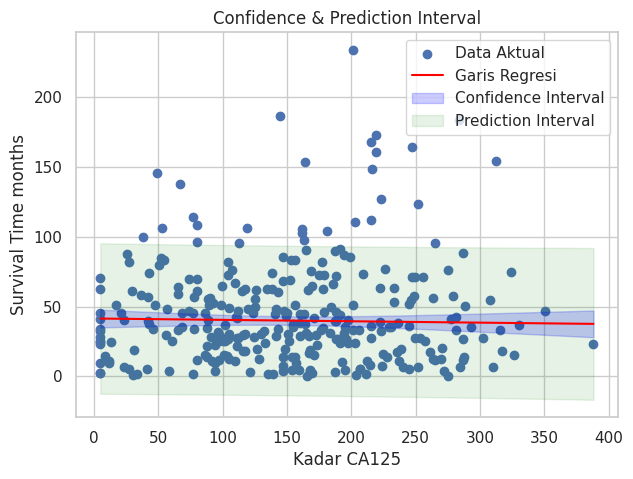


=== PREDIKSI MODEL ===
Prediksi dari data testing
     CA125 (X)  Survival Aktual (Y)  Survival Prediksi
203     173.64                 22.5          39.696840
266      23.33                 40.4          41.192557
152     163.92                153.7          39.793562
9       105.33                 48.8          40.376585
233     350.46                 46.8          37.937324

Prediksi kadar CA125 untuk Data Baru:
RLS = 7 → Prediksi kadar CA125 = 41.36%
RLS = 10 → Prediksi kadar CA125 = 41.33%


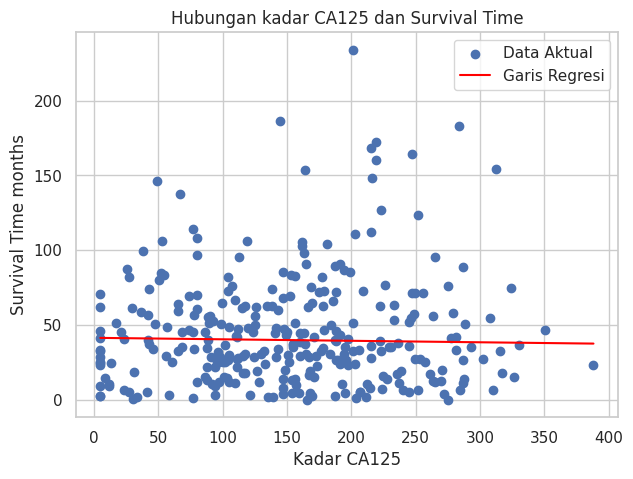


=== MENGHITUNG KOEFISIEN KORELASI PEARSON SEBAGAI METODE PERBANDINGAN, UJI SIGNIFIKANSI KORELASI, DAN INTERPRETASINYA===

=== KORELASI SPEARMAN ===
Koefisien Spearman: -0.032
P-value: 0.581
Interpretasi: Sangat lemah negatif
Kesimpulan: Tidak signifikan

=== PERBANDINGAN PEARSON VS SPEARMAN ===
Pearson  : -0.030
Spearman : -0.032
Hubungan cenderung linear (hasil konsisten)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


from google.colab import files
uploaded = files.upload()

# Setting visualisasi agar lebih rapi
sns.set_theme(style="whitegrid")
%matplotlib inline

# Load data
df = pd.read_csv('ovarian_cancer_survival_dataset.csv')
data = df[['CA125', 'Survival_Time_months']]
data.head()

# Cek Missing Values
total_missing = data.isna().sum().sum()
print("=== CEK MISSING VALUES ===")
print("Missing Value:", total_missing)

# Cek Outliers
print("\n=== CEK OUTLIERS ===")
sns.set_theme(style="whitegrid")

# Grubbs test manual
def grubbs_test(x, alpha=0.05):
    x_clean = x.dropna()
    n = len(x_clean)
    if n < 3:
        return "Data tidak cukup"

    mean_x = np.mean(x_clean)
    std_x = np.std(x_clean, ddof=1)
    G = np.max(np.abs(x_clean - mean_x)) / std_x

    t_dist = stats.t.ppf(1 - alpha / (2*n), n-2)
    G_crit = ((n-1)/np.sqrt(n)) * np.sqrt(t_dist**2 / (n-2 + t_dist**2))

    return "Terdeteksi" if G > G_crit else "Tidak terdeteksi"

# Fungsi deteksi, pembersihan, dan laporan sebelum & sesudah
def detect_clean_report(data, method='all', replace_with='median'):
    cleaned_data = data.copy()
    numeric_cols = data.select_dtypes(include='number').columns
    outlier_report = {}

    for var in numeric_cols:
        # Statistik IQR
        q1 = data[var].quantile(0.25)
        q3 = data[var].quantile(0.75)
        iqr_val = q3 - q1
        lower_bound = q1 - 1.5 * iqr_val
        upper_bound = q3 + 1.5 * iqr_val

        # Outlier sebelum pembersihan
        outliers_iqr_before = data[var][(data[var] < lower_bound) | (data[var] > upper_bound)]
        z_scores = (data[var] - data[var].mean()) / data[var].std()
        outliers_z_before = data[var][abs(z_scores) > 3]
        grubbs_before = grubbs_test(data[var])

        # Pembersihan data
        if replace_with == 'nan':
            if method == 'iqr':
                cleaned_data.loc[(cleaned_data[var] < lower_bound) | (cleaned_data[var] > upper_bound), var] = np.nan
            elif method == 'zscore':
                cleaned_data.loc[abs(z_scores) > 3, var] = np.nan
            elif method == 'all':
                cleaned_data.loc[((cleaned_data[var] < lower_bound) | (cleaned_data[var] > upper_bound)) | (abs(z_scores) > 3), var] = np.nan
        elif replace_with == 'median':
            median_val = data[var].median()
            if method == 'iqr':
                cleaned_data.loc[(cleaned_data[var] < lower_bound) | (cleaned_data[var] > upper_bound), var] = median_val
            elif method == 'zscore':
                cleaned_data.loc[abs(z_scores) > 3, var] = median_val
            elif method == 'all':
                cleaned_data.loc[((cleaned_data[var] < lower_bound) | (cleaned_data[var] > upper_bound)) | (abs(z_scores) > 3), var] = median_val

        # Outlier sesudah pembersihan
        outliers_iqr_after = cleaned_data[var][(cleaned_data[var] < lower_bound) | (cleaned_data[var] > upper_bound)]
        z_scores_after = (cleaned_data[var] - cleaned_data[var].mean()) / cleaned_data[var].std()
        outliers_z_after = cleaned_data[var][abs(z_scores_after) > 3]
        grubbs_after = grubbs_test(cleaned_data[var])

        # Simpan report
        outlier_report[var] = {
            'sebelum': {
                'n_outliers_iqr': len(outliers_iqr_before),
                'n_outliers_z': len(outliers_z_before),
                'grubbs': grubbs_before,
                'outlier_values': np.round(outliers_iqr_before.unique(),2).tolist()
            },
            'sesudah': {
                'n_outliers_iqr': len(outliers_iqr_after),
                'n_outliers_z': len(outliers_z_after),
                'grubbs': grubbs_after,
                'outlier_values': np.round(outliers_iqr_after.unique(),2).tolist()
            }
        }

        # Print laporan ringkas
        print(f"\n=== Variabel: {var} ===")
        print("Sebelum pembersihan:")
        print(f"Outlier (IQR): {len(outliers_iqr_before)}, Outlier (Z-score > 3): {len(outliers_z_before)}, Grubbs: {grubbs_before}")
        if len(outliers_iqr_before) > 0:
            print("Contoh nilai outlier:", ", ".join(map(str, np.round(outliers_iqr_before.unique()[:5],2))))

        print("Sesudah pembersihan:")
        print(f"Outlier (IQR): {len(outliers_iqr_after)}, Outlier (Z-score > 3): {len(outliers_z_after)}, Grubbs: {grubbs_after}")
        if len(outliers_iqr_after) > 0:
            print("Contoh nilai outlier:", ", ".join(map(str, np.round(outliers_iqr_after.unique()[:5],2))))

    # Visualisasi boxplot sebelum dan sesudah
    for var in numeric_cols:
        plt.figure(figsize=(12,5))

        # Sebelum
        plt.subplot(1,2,1)
        sns.boxplot(y=data[var])
        plt.title(f'{var} - Sebelum pembersihan')

        # Sesudah
        plt.subplot(1,2,2)
        sns.boxplot(y=cleaned_data[var])
        plt.title(f'{var} - Sesudah pembersihan')

        plt.tight_layout()
        plt.show()

    return cleaned_data, outlier_report

# Jalankan fungsi
cleaned_data, outlier_analysis = detect_clean_report(data, method='all', replace_with='median')

print("\n=== CEK INCONSISTENCY ===")
print(f"CA125 negatif: {(df['CA125'] < 0).sum()}")
print(f"Survival_Time_months negatif: {(df['Survival_Time_months'] < 0).sum()}")
print(f"Duplikasi data: {df.duplicated().sum()}")

print("\n=== ANALISIS DESKRIPTIF STATISTIK PADA DATA===")
sns.set_theme(style="whitegrid")

numeric_cols = data.select_dtypes(include='number').columns

for var in numeric_cols:
    print(f"--- Variabel: {var} ---")

    # Statistik dasar
    count = data[var].count()
    missing = data[var].isna().sum()
    mean = data[var].mean()
    median = data[var].median()
    std = data[var].std()
    min_val = data[var].min()
    max_val = data[var].max()
    q1 = data[var].quantile(0.25)
    q3 = data[var].quantile(0.75)

     # Inconsistency: nilai negatif
    inconsistency_neg = (data[var] < 0).sum()
    # Duplikasi data
    duplicate_count = data.duplicated().sum()

    print(f"Count: {count}")
    print(f"Missing: {missing}")
    print(f"Mean: {mean:.2f}")
    print(f"Median: {median:.2f}")
    print(f"Std Dev: {std:.2f}")
    print(f"Min: {min_val}")
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"Max: {max_val}")
    print(f"Nilai negatif (inconsistency): {inconsistency_neg}")
    print(f"Duplikasi data: {duplicate_count}")

    # Outlier menggunakan IQR
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = data[var][(data[var] < lower_bound) | (data[var] > upper_bound)]
    print(f"Jumlah outlier (IQR method): {len(outliers)}\n")

    # Visualisasi distribusi
    plt.figure(figsize=(12,5))

    # Histogram
    plt.subplot(1,2,1)
    sns.histplot(data[var], kde=True, bins=15)
    plt.title(f'{var} - Histogram')

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(y=data[var])
    plt.title(f'{var} - Boxplot')

    plt.tight_layout()
    plt.show()

    from scipy.stats import pearsonr

print("\n=== MENGHITUNG KOEFISIEN KORELASI PEARSON, UJI SIGNIFIKANSI KORELASI, DAN INTERPRETASINYA===")
# Nama variabel
x = 'CA125'
y = 'Survival_Time_months'

variabel_x = cleaned_data[x]
variabel_y = cleaned_data[y]

hasil_korelasi = {}

# Menghitung Koefisien Korelasi Pearson
korelasi_pearson, p_value = pearsonr(variabel_x, variabel_y)
hasil_korelasi[(x, y)] = (korelasi_pearson, p_value)

print(f"\nKorelasi Pearson antara {x} dan {y}: {korelasi_pearson:.3f}")

# --- Interpretasi kekuatan korelasi ---
if korelasi_pearson > 0.8:
    interpretasi = "Korelasi sangat kuat positif"
elif korelasi_pearson > 0.6:
    interpretasi = "Korelasi kuat positif"
elif korelasi_pearson > 0.4:
    interpretasi = "Korelasi sedang positif"
elif korelasi_pearson > 0.2:
    interpretasi = "Korelasi lemah positif"
elif korelasi_pearson > 0:
    interpretasi = "Korelasi sangat lemah positif"
elif korelasi_pearson < -0.8:
    interpretasi = "Korelasi sangat kuat negatif"
elif korelasi_pearson < -0.6:
    interpretasi = "Korelasi kuat negatif"
elif korelasi_pearson < -0.4:
    interpretasi = "Korelasi sedang negatif"
elif korelasi_pearson < -0.2:
    interpretasi = "Korelasi lemah negatif"
elif korelasi_pearson < 0:
    interpretasi = "Korelasi sangat lemah negatif"
else:
    interpretasi = "Tidak ada korelasi linier"

print("Interpretasi:", interpretasi)

# Tetapkan tingkat signifikansi (alpha)
alpha = 0.05
print(f"Koefisien Korelasi Pearson: {korelasi_pearson:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"Tingkat Signifikansi (alpha): {alpha}")

# Lakukan uji hipotesis
if p_value < alpha:
  keputusan = "Tolak Hipotesis Nol (H0)"
  interpretasi_uji = "Ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier yang signifikan antara kadar CA125 dan Survival Time months."
else:
  keputusan = "Gagal Menolak Hipotesis Nol (H0)"
  interpretasi_uji = "Tidak ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier yang signifikan antara kadar CA125 dan Survival Time months."

print(f"\nKeputusan: {keputusan}")
print(f"Interpretasi Uji: {interpretasi_uji}")

print("\n=== POLA HUBUNGAN ANTAR VARIABEL===")
plt.figure(figsize=(6,4))
sns.scatterplot(x=variabel_x, y=variabel_y)
sns.regplot(x=variabel_x, y=variabel_y, scatter=False, color='red')
plt.title("Scatter Plot Hubungan Variabel")
plt.xlabel(x)
plt.ylabel(y)
plt.show()

print("\n=== MODEL REGRESI LINEAR SEDERHANA===")
import statsmodels.api as sm

# Variabel X dan Y
X = cleaned_data['CA125']
Y = cleaned_data['Survival_Time_months']

# Tambahkan konstanta (intercept)
X = sm.add_constant(X)

# Model regresi linear sederhana
model = sm.OLS(Y, X).fit()

# Ambil koefisien
beta0 = model.params.iloc[0]  # intercept
beta1 = model.params.iloc[1]  # slope

# Ambil R-squared
r_squared = model.rsquared

# Ambil p-value untuk slope
p_value = model.pvalues.iloc[1]

# Cetak ringkasan model
print(model.summary())

# Interpretasi otomatis
print("\n=== INTERPRETASI MODEL REGRESI LINEAR SEDERHANA ===")

# Koefisien
if beta1 < 0:
    arah = "berbanding terbalik (negatif)"
else:
    arah = "searah (positif)"

print(f"Koefisien regresi (slope) = {beta1:.3f}, menunjukkan bahwa setiap kenaikan 1 tahun Survival Time months, CA125 {('menurun' if beta1 < 0 else 'meningkat')} ({arah}).")

# R-squared
print(f"Koefisien determinasi (R²) = {r_squared:.3f}, artinya model menjelaskan {r_squared*100:.1f}% variasi kadar CA125, sisanya dipengaruhi faktor lain di luar model.")

# Signifikansi
alpha = 0.05
if p_value < alpha:
    print(f"P-value = {p_value:.5f} < {alpha}, artinya pengaruh Survival Time months terhadap kadar CA125 signifikan secara statistik.")
else:
    print(f"P-value = {p_value:.5f} >= {alpha}, artinya pengaruh Survival Time months terhadap kadar CA125 **tidak signifikan** secara statistik.")

print("\n=== UJI ASUMSI REGRESI LINEAR ===")
print("\n1. UJI NORMALITAS RESIDUAL (Shapiro-Wilk):\n")
from scipy.stats import shapiro

# Ambil residual dari model
residuals = model.resid

# Uji normalitas Shapiro-Wilk
shapiro_test = shapiro(residuals)

# Cetak hasil
print(f"Statistik Uji W = {shapiro_test.statistic:.4f}")
print(f"P-value = {shapiro_test.pvalue:.4f}")

# Interpretasi
alpha = 0.05
if shapiro_test.pvalue > alpha:
    print("Kesimpulan: Residual berdistribusi normal (gagal menolak H0).")
else:
    print("Kesimpulan: Residual tidak berdistribusi normal (Tolak H0).")

plt.figure(figsize=(15,4))

# Histogram residual
plt.subplot(1,3,1)
sns.histplot(residuals, kde=True, bins=15, color='skyblue')
plt.title("Histogram Residual")
plt.xlabel("Residual")
plt.ylabel("Frekuensi")
plt.show()

print("\n2. UJI HOMOSKEDASTISITAS (Breusch-Pagan):")
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.nonparametric.smoothers_lowess import lowess

# Ambil residual dan variabel independen
residuals = model.resid
X = model.model.exog  # variabel termasuk intercept

# Uji Breusch-Pagan
bp_test = het_breuschpagan(residuals, X)

# Output
lm_stat = bp_test[0]       # LM statistic
lm_pvalue = bp_test[1]     # p-value
f_stat = bp_test[2]        # F-statistic
f_pvalue = bp_test[3]      # p-value F

# Cetak hasil
print(f"Statistik Uji LM = {lm_stat:.4f}")
print(f"P-value LM = {lm_pvalue:.4f}")

# Interpretasi
alpha = 0.05
if lm_pvalue > alpha:
    print("Kesimpulan: Residual memenuhi asumsi homoskedastisitas (gagal menolak H0).")
else:
    print("Kesimpulan: Residual tidak homogen (Tolak H0), terjadi heteroskedastisitas.")

fitted = model.fittedvalues

# Plot homoskedastisitas
plt.scatter(fitted, residuals, color='orange', alpha=0.6)
plt.axhline(0, color='black', linestyle='--')
plt.plot(lowess(residuals, fitted)[:,0], lowess(residuals, fitted)[:,1], color='blue', linewidth=2)
plt.title("Residuals vs Fitted (Homoskedastisitas)")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()


print("\n===IDENTIFIKASI MASALAH MODEL=== :")
# Normalitas
if shapiro_test.pvalue < 0.05:
    print("- Residual tidak normal → bisa gunakan transformasi (log) atau robust regression")

# Heteroskedastisitas
if bp_test[1] < 0.05:
    print("- Terjadi heteroskedastisitas → gunakan Weighted Least Squares / robust standard error")
else:
    print("- Tidak ditemukan pelanggaran asumsi utama")

print("\nMEMBAGI DATA MENJADI TRAINING DAN TESTING SET:")
from sklearn.model_selection import train_test_split

X = data[['CA125']]
y = data['Survival_Time_months']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))

print("\nVALIDASI MODEL DAN METRIK PERFORMA:")
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Prediksi data testing
X_test_sm = sm.add_constant(X_test)
y_pred = model.predict(X_test_sm)

# ================================
# METRIK PERFORMA
# ================================
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("METRIK PERFORMA MODEL")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

print("\nINTERPRETASI:")

print(f"- Nilai RMSE sebesar {rmse:.2f} menunjukkan rata-rata kesalahan prediksi sekitar {rmse:.2f} satuan.")
print(f"- Nilai MAE sebesar {mae:.2f} menunjukkan rata-rata selisih absolut antara prediksi dan data aktual.")

if r2 < 0.3:
    print(f"- Nilai R² = {r2:.4f} menunjukkan kemampuan model dalam menjelaskan variasi data masih rendah.")
elif r2 < 0.7:
    print(f"- Nilai R² = {r2:.4f} menunjukkan kemampuan model dalam kategori sedang.")
else:
    print(f"- Nilai R² = {r2:.4f} menunjukkan model memiliki kemampuan yang baik.")

print("- Model masih bisa ditingkatkan dengan menambahkan variabel lain.")


print("\n=== CONFIDENCE INTERVAL DAN PREDICTION INTERVAL ===")

# Confidence interval untuk parameter model
conf_int = model.conf_int(alpha=0.05)
conf_int.columns = ['Lower Bound', 'Upper Bound']
print("\nConfidence Interval Koefisien:")
print(conf_int)

# Prediction interval untuk data testing
prediksi_interval = model.get_prediction(X_test_sm)
summary_frame = prediksi_interval.summary_frame(alpha=0.05)

print("\nPrediction Interval (5 data pertama):")
print(summary_frame[['mean', 'mean_ci_lower', 'mean_ci_upper',
                     'obs_ci_lower', 'obs_ci_upper']].head())

# Visualisasi confidence & prediction interval
plt.figure(figsize=(7,5))

plt.scatter(X, y, label="Data Aktual")

# Garis regresi
X_line = np.linspace(df['CA125'].min(), df['CA125'].max(), 100)
X_line_df = pd.DataFrame({'CA125': X_line})
X_line_sm = sm.add_constant(X_line_df)

y_line = model.predict(X_line_sm)
plt.plot(X_line, y_line, color='red', label="Garis Regresi")

# Confidence interval
plt.fill_between(X_line.flatten(),
                 model.get_prediction(X_line_sm).summary_frame()['mean_ci_lower'],
                 model.get_prediction(X_line_sm).summary_frame()['mean_ci_upper'],
                 color='blue', alpha=0.2, label='Confidence Interval')

# Prediction interval
plt.fill_between(X_line.flatten(),
                 model.get_prediction(X_line_sm).summary_frame()['obs_ci_lower'],
                 model.get_prediction(X_line_sm).summary_frame()['obs_ci_upper'],
                 color='green', alpha=0.1, label='Prediction Interval')

plt.xlabel("Kadar CA125")
plt.ylabel("Survival Time months")
plt.title("Confidence & Prediction Interval")
plt.legend()
plt.show()


print("\n=== PREDIKSI MODEL ===")

print("Prediksi dari data testing")
hasil_prediksi = pd.DataFrame({
    'CA125 (X)': X_test['CA125'],
    'Survival Aktual (Y)': y_test,
    'Survival Prediksi': y_pred
})

print(hasil_prediksi.head())


# Data baru
data_baru = pd.DataFrame({
    'CA125': [7, 10]
})

# Tambahkan konstanta
data_baru_sm = sm.add_constant(data_baru)

# Prediksi
prediksi_baru = model.predict(data_baru_sm)

print("\nPrediksi kadar CA125 untuk Data Baru:")
for i, val in enumerate(prediksi_baru):
    print(f"RLS = {data_baru.iloc[i,0]} → Prediksi kadar CA125 = {val:.2f}%")

plt.figure(figsize=(7,5))

# Scatter data asli
plt.scatter(X, y, label="Data Aktual")

# Garis regresi
X_line = np.linspace(X.min(), X.max(), 100)
X_line_df = pd.DataFrame(X_line, columns=X.columns)
X_line_sm = sm.add_constant(X_line_df)

y_line = model.predict(X_line_sm)

plt.plot(X_line, y_line, color='red', label="Garis Regresi")

plt.xlabel("Kadar CA125")
plt.ylabel("Survival Time months")
plt.title("Hubungan kadar CA125 dan Survival Time")
plt.legend()
plt.show()


print("\n=== MENGHITUNG KOEFISIEN KORELASI PEARSON SEBAGAI METODE PERBANDINGAN, UJI SIGNIFIKANSI KORELASI, DAN INTERPRETASINYA===")
print("\n=== KORELASI SPEARMAN ===")

from scipy.stats import spearmanr

# Hitung Spearman
korelasi_spearman, p_value_spear = spearmanr(variabel_x, variabel_y)

# Output utama
print(f"Koefisien Spearman: {korelasi_spearman:.3f}")
print(f"P-value: {p_value_spear:.3f}")

# Interpretasi kekuatan
if korelasi_spearman > 0.8:
    interpretasi_s = "Sangat kuat positif"
elif korelasi_spearman > 0.6:
    interpretasi_s = "Kuat positif"
elif korelasi_spearman > 0.4:
    interpretasi_s = "Sedang positif"
elif korelasi_spearman > 0.2:
    interpretasi_s = "Lemah positif"
elif korelasi_spearman > 0:
    interpretasi_s = "Sangat lemah positif"
elif korelasi_spearman < -0.8:
    interpretasi_s = "Sangat kuat negatif"
elif korelasi_spearman < -0.6:
    interpretasi_s = "Kuat negatif"
elif korelasi_spearman < -0.4:
    interpretasi_s = "Sedang negatif"
elif korelasi_spearman < -0.2:
    interpretasi_s = "Lemah negatif"
elif korelasi_spearman < 0:
    interpretasi_s = "Sangat lemah negatif"
else:
    interpretasi_s = "Tidak ada korelasi"

print("Interpretasi:", interpretasi_s)

# Uji signifikansi
alpha = 0.05
if p_value_spear < alpha:
    print("Kesimpulan: Signifikan (ada hubungan monotonic)")
else:
    print("Kesimpulan: Tidak signifikan")

print("\n=== PERBANDINGAN PEARSON VS SPEARMAN ===")

print(f"Pearson  : {korelasi_pearson:.3f}")
print(f"Spearman : {korelasi_spearman:.3f}")

if abs(korelasi_pearson - korelasi_spearman) < 0.1:
    print("Hubungan cenderung linear (hasil konsisten)")
else:
    print("Hubungan cenderung tidak linear (monotonik)")